In [1]:
import torch, cv2, mediapipe, onnxruntime, sklearn, scipy, statsmodels, psutil, pandas

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))
print("OpenCV:", cv2.__version__)
print("MediaPipe:", mediapipe.__version__)
print("ONNX Runtime:", onnxruntime.__version__)
print("scikit-learn:", sklearn.__version__)
print("SciPy:", scipy.__version__)
print("statsmodels:", statsmodels.__version__)
print("RAM total (GB):", round(psutil.virtual_memory().total / 1e9, 1))

x = torch.randn(1000, 1000, device="cuda")
print("Multiplicación en GPU OK:", (x @ x).shape)

PyTorch: 2.11.0+cu128
CUDA disponible: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
OpenCV: 5.0.0
MediaPipe: 1.0.1
ONNX Runtime: 1.30.0
scikit-learn: 1.9.1
SciPy: 1.17.1
statsmodels: 0.15.0
RAM total (GB): 16.9
Multiplicación en GPU OK: torch.Size([1000, 1000])


Rostros detectados: 1
Landmarks por rostro: 478


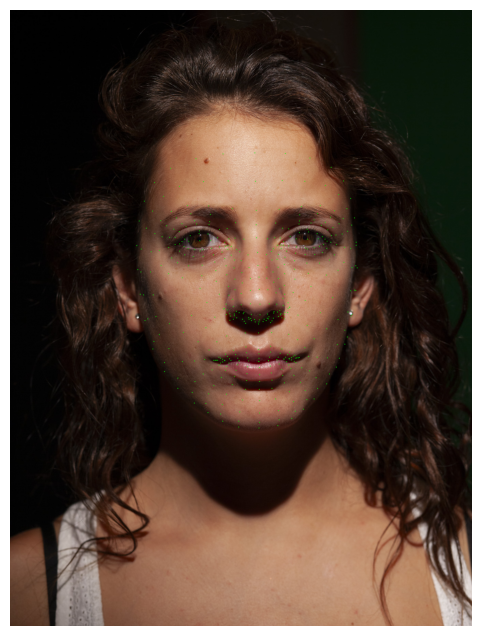

In [2]:
import mediapipe as mp
import cv2
from matplotlib import pyplot as plt

BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
RunningMode = mp.tasks.vision.RunningMode

opts = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path="models/face_landmarker.task"),
    running_mode=RunningMode.IMAGE,
    num_faces=1,
)

with FaceLandmarker.create_from_options(opts) as detector:
    img = mp.Image.create_from_file("data/raw/prueba.jpg")
    res = detector.detect(img)

print("Rostros detectados:", len(res.face_landmarks))
print("Landmarks por rostro:", len(res.face_landmarks[0]))

frame = cv2.imread("data/raw/prueba.jpg")
h, w = frame.shape[:2]
for lm in res.face_landmarks[0]:
    cv2.circle(frame, (int(lm.x * w), int(lm.y * h)), 1, (0, 255, 0), -1)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()